<a href="https://colab.research.google.com/github/leah-mogotsi/Final_exam/blob/main/Leah_practical_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. PROBLEM FRAMING**
This a dataset containing various messages. The goal is determine whether a particular message is spam or ham, basically if its legitimate or not.
The spam messages contain keywords like "win", which the model is supposed to identify as key indicator of a fraudulent message.

The files contain one message per line. Each line is composed by two columns: v1 contains the label (ham or spam) and v2 contains the raw text.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


# 2. Data Understanding

In [ ]:
df = pd.read_csv('/content/spam.csv', encoding='ISO-8859-1', usecols=['v1','v2'])

In [ ]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.isnull().sum()

,0
v1,0
v2,0


In [ ]:
df.shape

(5572, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['v1'].count()

np.int64(5572)

3. EDA

Text(0.5, 1.0, 'Spam vs Ham Count')

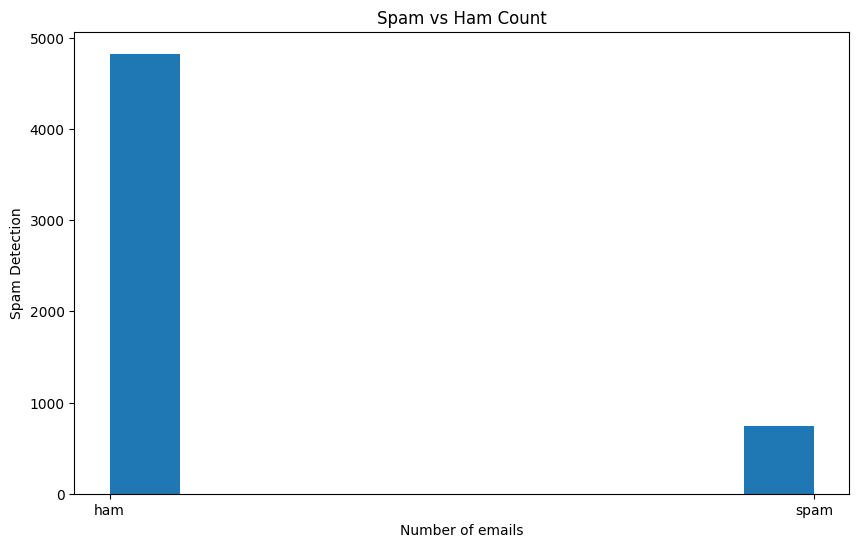

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df['v1'], bins = 10)
plt.ylabel("Spam Detection")
plt.xlabel("Number of emails")
plt.title("Spam vs Ham Count")

Interpretation: There are more ham emails than spam emails, so the data set is very imbalanced, which could make the model to be biased.

In [ ]:
!pip install nltk

In [ ]:
import nltk

In [ ]:
import nltk

def clean(text):
  text = text.strip()
  text = text.lower()
  text = text.replace("%, ., ")
  return nltk.word_tokenize(text)

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import nltk


In [ ]:
import re
import string

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
df["v2"] = df["v2"].apply(clean_text)
df["v2"].head()

,v2
0,go until jurong point crazy available only in ...
1,ok lar joking wif u oni
2,free entry in a wkly comp to win fa cup final ...
3,u dun say so early hor u c already then say
4,nah i dont think he goes to usf he lives aroun...


# **6. Pre-Processing**

In [ ]:
df['v2'].apply(clean)

,v2
0,"[go, until, jurong, point, ,, crazy, .., avail..."
1,"[ok, lar, ..., joking, wif, u, oni, ...]"
2,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,"[u, dun, say, so, early, hor, ..., u, c, alrea..."
4,"[nah, i, do, n't, think, he, goes, to, usf, ,,..."
...,...
5567,"[this, is, the, 2nd, time, we, have, tried, 2,..."
5568,"[will, ì_, b, going, to, esplanade, fr, home, ?]"
5569,"[pity, ,, *, was, in, mood, for, that, ., so, ..."
5570,"[the, guy, did, some, bitching, but, i, acted,..."


Because machine learning models cannot interpret text, we have to encode the text as follows.

In [ ]:
df['v1'] = df['v1'].map({
    'ham': 0,
    'spam': 1
})

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df['v2']
y = df['v1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train_tfidf, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9623318385650225


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       966
           1       0.87      0.84      0.86       149

    accuracy                           0.96      1115
   macro avg       0.92      0.91      0.92      1115
weighted avg       0.96      0.96      0.96      1115



In [157]:
import joblib

joblib.dump(model, "nltk.pkl")

['nltk.pkl']

In [158]:
from google.colab import files
files.download("nltk.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [159]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 70.8 MB/s eta 0:00:00


In [165]:

import streamlit as st
import joblib
import numpy as np

model = joblib.load("nltk.pkl")

st.title("Spam Detection App")

text = st.text_input("Enter message received")


if st.button("Predict"):

    features = np.array([[text]])

    prediction = model.predict(features)

    st.success(f"Estimated Price: {prediction[0]}")

2026-03-28 11:44:13.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 11:44:13.230 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 11:44:13.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 11:44:13.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 11:44:13.237 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 11:44:13.240 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 11:44:13.243 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 11:44:13.246 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [162]:
import joblib

joblib.dump(model, "nltk.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [166]:
code = """

import streamlit as st
import joblib
import numpy as np

model = joblib.load("nltk.pkl")

st.title("Spam Detection App")

text = st.text_input("Enter message received")


if st.button("Predict"):

    features = np.array([[text]])

    prediction = model.predict(features)

    st.success(f"Estimated Price: {prediction[0]}")
    """
with open("app.py", "w") as f:
  f.write(code)

In [164]:
with open("requirements.txt", "w") as f:
  f.write("streamlit\nnumpy\nscikit-learn\njoblib")